# Group 3 Module III Project — Movie Industry Data Analysis

![ChatGPT Image Aug 17, 2026, 07_20_33 PM.png](<attachment:ChatGPT Image Aug 17, 2026, 07_20_33 PM.png>)
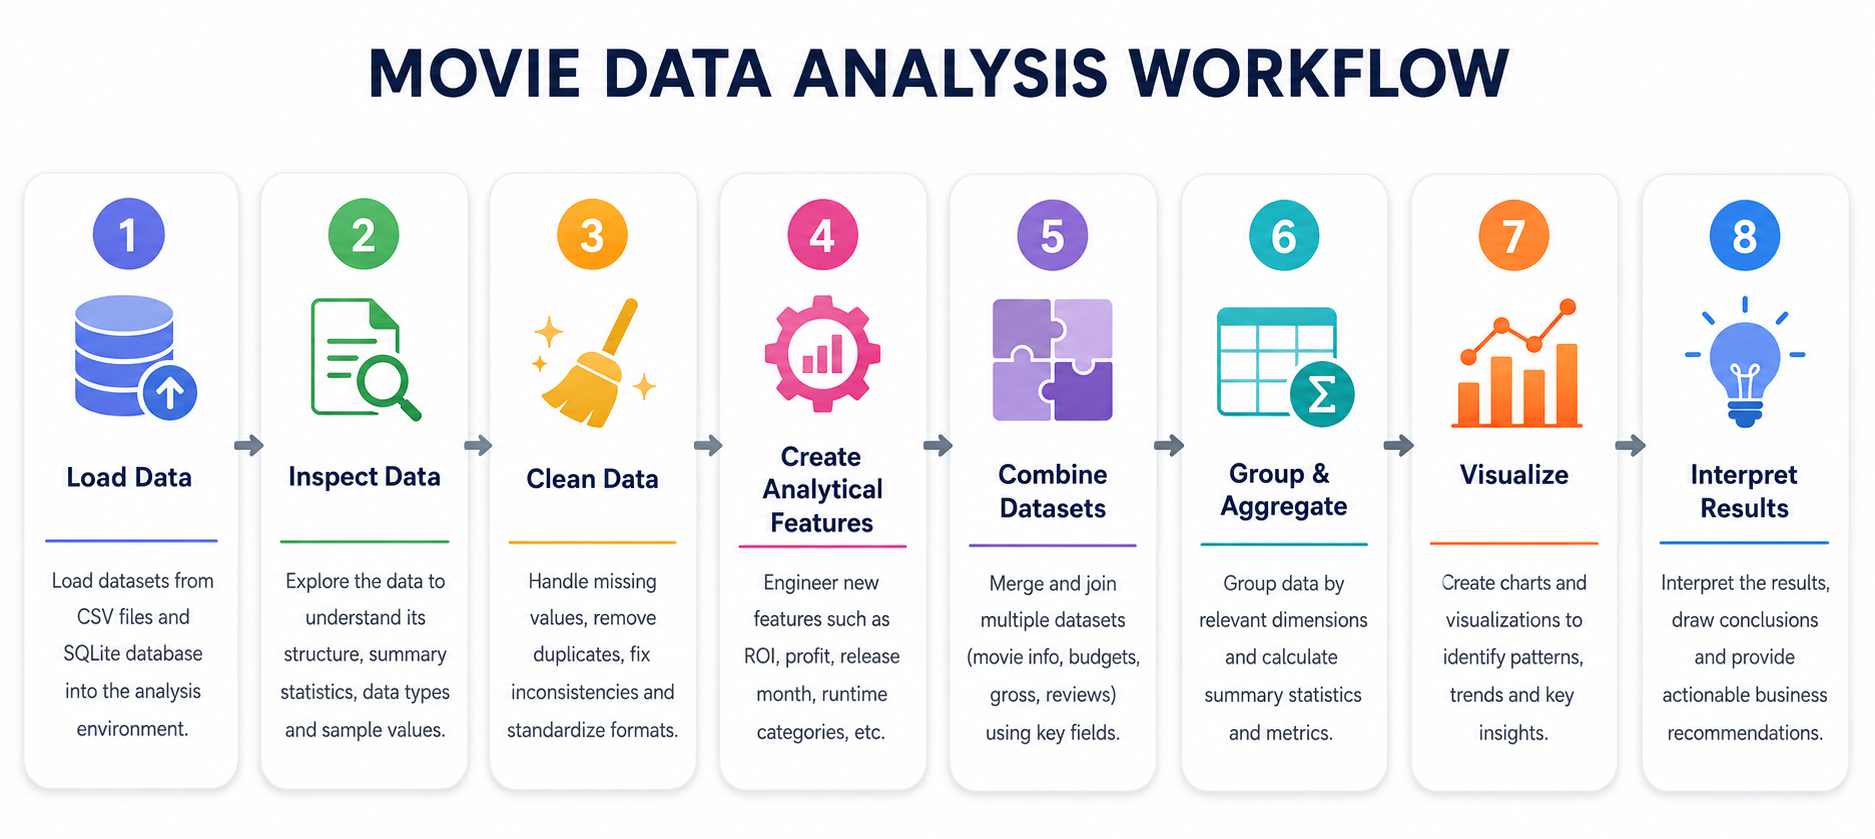

## CRISP-DM: 1. Business Understanding

This project follows the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** framework to guide the analysis from the business problem through to actionable recommendations.

### CRISP-DM Phases Used in This Project
1. **Business Understanding** — define the business problem, objectives and questions.
2. **Data Understanding** — load, inspect and assess the available datasets.
3. **Data Preparation** — clean, transform and prepare the data for analysis.
4. **Modeling / Analytical Methods** — apply grouping, aggregation, ROI analysis and relationship analysis to answer the business questions.
5. **Evaluation** — assess whether the findings answer the original business questions.
6. **Deployment / Recommendations** — translate the findings into practical business actions.

## 1.1 Business Context

We are establishing a new movie studio, but the company has no significant experience in the movie industry. This creates a strategic decision problem: **what type of movies should the new studio produce to maximize its chances of commercial success?**

We use historical movie data to identify patterns in **box-office performance, production investment, release timing, genre and audience ratings**. The goal is to turn the data into insights that support decisions about **what to produce, when to release it and how to manage production investment**.

## 1.2 Business Questions

The analysis is designed to answer three management questions:

1. **Which movie genres should the new studio consider investing in?**
   - Which genres have historically produced strong returns?
   - Which genres demonstrate stronger median ROI?

2. **Which time of the year is best to release movies?**
   - Which release months have the highest average worldwide gross?
   - How does release volume vary by month?

3. **How does production budget relate to movie performance?**
   - Does a higher production budget correspond with higher worldwide gross?
   - Does production budget appear to be related to audience rating?

## CRISP-DM: 2. Data Understanding

### 2.1 Import relevant Libraries & Load the Available Source Data

The project contains movie financial, genre, ratings and review information in CSV/TSV files, together with an IMDb SQLite database.

We first load the available sources so we can understand what information is available for the business questions.

In [1]:
# Import Pandas for data manipulation and analysis.
import pandas as pd

# Import sqlite3 to query the IMDb SQLite database.
import sqlite3

# Import Matplotlib for creating charts.
import matplotlib.pyplot as plt

# Import NumPy for numerical operations and conditional logic.
import numpy as np

# Import Seaborn for statistical plots and regression lines.
import seaborn as sns

In [2]:
# CSV files
bom_movie_gross = pd.read_csv("data/bom.movie_gross.csv/bom.movie_gross.csv")

tmdb_movies = pd.read_csv("data/tmdb.movies.csv/tmdb.movies.csv", index_col=0)

tn_movie_budgets = pd.read_csv("data/tn.movie_budgets.csv/tn.movie_budgets.csv")

# TSV files
rt_movie_info = pd.read_csv(
    "data/rt.movie_info.tsv/rt.movie_info.tsv",
    sep="\t"
)

rt_reviews = pd.read_csv(
    "data/rt.reviews.tsv/rt.reviews.tsv",
    sep="\t", encoding="latin1"
)

### 2.2 Connect to the IMDb SQLite Database

The SQLite database provides structured IMDb information that complements the financial datasets. We establish a connection so relevant tables can be inspected and queried using SQL.

In [4]:
# SQLite database
conn = sqlite3.connect("data/im.db/im.db")

### 2.3 Explore the Available Datasets

Before cleaning or combining data, we inspect the datasets to understand their **structure, columns, data types, identifiers and sample values**. This helps determine which sources and fields are relevant to the business questions.

#### Movies Earnings (needed)

In [5]:
bom_movie_gross.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


#### Movie Genres and Ratings

In [6]:
tmdb_movies.head()

,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


In [7]:
tmdb_movies["original_language"].unique()

array(['en', 'nl', 'es', 'ja', 'sv', 'de', 'fr', 'cn', 'it', 'ru', 'zh',
       'hi', 'no', 'ko', 'da', 'fi', 'pl', 'te', 'hu', 'tr', 'pt', 'he',
       'fa', 'th', 'cs', 'et', 'tl', 'lt', 'xx', 'bs', 'ar', 'is', 'el',
       'mr', 'hr', 'ro', 'sr', 'uk', 'nb', 'hz', 'ca', 'bg', 'sl', 'lv',
       'si', 'ab', 'ta', 'bo', 'id', 'sq', 'bn', 'gu', 'lo', 'ne', 'kk',
       'hy', 'ps', 'kn', 'vi', 'ku', 'ka', 'ml', 'ur', 'mi', 'eu', 'sn',
       'cy', 'ha', 'ky', 'yi', 'pa', 'xh', 'cr', 'sw', 'af', 'dz'],
      dtype=object)

In [8]:
tmdb_movies.dtypes

genre_ids             object
id                     int64
original_language     object
original_title        object
popularity           float64
release_date          object
title                 object
vote_average         float64
vote_count             int64
dtype: object

#### Movie Earnings

In [9]:
tn_movie_budgets.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [10]:
tn_movie_budgets.shape

(5782, 6)

In [11]:
tn_movie_budgets["id"].nunique()

100

#### Movie Reviews

In [12]:
rt_reviews.head()

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"


In [13]:
rt_reviews.shape

(54432, 8)

In [14]:
rt_reviews["id"].nunique()

1135

### 2.4 Explore the IMDb SQLite Database

The database contains multiple IMDb tables. We inspect the available tables and sample records to identify the fields needed for the analysis.

#### Identify Available Tables

List all tables in the SQLite database before selecting the tables required for the analysis.

In [15]:
tables = pd.read_sql("""
    SELECT name
    FROM sqlite_master
    WHERE type='table';
""", conn)

display(tables)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [16]:
movie_basics = pd.read_sql(
    "SELECT * FROM movie_basics LIMIT 5",
    conn
)

display(movie_basics)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [17]:
directors = pd.read_sql(
    "SELECT * FROM directors LIMIT 5",
    conn
)

display(directors)

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502


In [18]:
known_for = pd.read_sql(
    "SELECT * FROM known_for LIMIT 5",
    conn
)

display(known_for)

,person_id,movie_id
0,nm0061671,tt0837562
1,nm0061671,tt2398241
2,nm0061671,tt0844471
3,nm0061671,tt0118553
4,nm0061865,tt0896534


In [19]:
movie_ratings = pd.read_sql(
    "SELECT * FROM movie_ratings LIMIT 5",
    conn
)

display(movie_ratings)

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [20]:
movie_ratings = pd.read_sql(
    "SELECT * FROM movie_ratings LIMIT 5",
    conn
)

display(movie_ratings)

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [21]:
persons = pd.read_sql(
    "SELECT * FROM persons LIMIT 5",
    conn
)

display(persons)

,person_id,primary_name,birth_year,death_year,primary_profession
0,nm0061671,Mary Ellen Bauder,None,None,"miscellaneous,production_manager,producer"
1,nm0061865,Joseph Bauer,None,None,"composer,music_department,sound_department"
2,nm0062070,Bruce Baum,None,None,"miscellaneous,actor,writer"
3,nm0062195,Axel Baumann,None,None,"camera_department,cinematographer,art_department"
4,nm0062798,Pete Baxter,None,None,"production_designer,art_department,set_decorator"


In [22]:
principals = pd.read_sql(
    "SELECT * FROM principals LIMIT 5",
    conn
)

display(principals)

,movie_id,ordering,person_id,category,job,characters
0,tt0111414,1,nm0246005,actor,None,"[""The Man""]"
1,tt0111414,2,nm0398271,director,None,None
2,tt0111414,3,nm3739909,producer,producer,None
3,tt0323808,10,nm0059247,editor,None,None
4,tt0323808,1,nm3579312,actress,None,"[""Beth Boothby""]"


In [23]:
writers = pd.read_sql(
    "SELECT * FROM writers LIMIT 5",
    conn
)

display(writers)

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0438973,nm0175726
2,tt0438973,nm1802864
3,tt0462036,nm1940585
4,tt0835418,nm0310087


## CRISP-DM: 3. Data Preparation

### a) Prepare the Movie Budget Dataset

The movie budget dataset is the foundation for the financial analysis. Before calculating profit, ROI or release-month performance, we prepare the monetary and date fields so they can be used reliably in calculations.

### b) Load the Movie Budgets CSV

Read the movie budgets CSV file into a Pandas DataFrame called `df`.

At this stage, the dataset is loaded but has not yet been cleaned.


In [24]:
# Load the movie budget dataset into the main working DataFrame.
# This dataset provides production budget, domestic gross, worldwide gross and release date.
df = pd.read_csv('data/tn.movie_budgets.csv/tn.movie_budgets.csv')

### c) Inspect the Dataset

Display the first five rows to understand the structure of the dataset, including the available columns and the format of the values.


In [25]:
# Display the first five rows to get an initial view of the dataset.
df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


### d) Clean the Monetary Columns

The budget and gross columns contain values formatted as strings, for example:

`$425,000,000`

To perform mathematical calculations, we:

1. Store the relevant column names in a Python list.
2. Use a `for` loop to process each column.
3. Remove the dollar sign (`$`).
4. Remove commas (`,`).
5. Convert the cleaned strings to `int64`.

This combines the concepts of a **Python list** and a **for loop** to avoid repeating the same code for every monetary column.


In [26]:
# Store the monetary columns in a list so the same cleaning procedure
# can be applied consistently using one loop.
budget_and_gross_cols = ['production_budget', 'domestic_gross', 'worldwide_gross']

for dollars in budget_and_gross_cols:
    # Remove the dollar sign from currency-formatted strings.
    df[dollars] = df[dollars].str.replace('$', '', regex=False)

    # Remove commas so values such as 425,000,000 can become numeric.
    df[dollars] = df[dollars].str.replace(',', '', regex=False)

    # Convert the cleaned text values to integers for calculations.
    df[dollars] = df[dollars].astype('int64')

### e) Inspect the Data After Cleaning

Check the first few rows again to confirm that the monetary columns have been cleaned successfully.


In [27]:
# Confirm that the monetary values are now displayed without "$" and commas.
df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000,760507625,2776345279
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875
2,3,"Jun 7, 2019",Dark Phoenix,350000000,42762350,149762350
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000,459005868,1403013963
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747


### f) Convert the Release Date and Extract the Release Month

The `release_date` column is converted from text to Pandas datetime format.

Once it is a datetime column, we can use `.dt.month` to extract the month number and create a new `release_month` column.

This new column will later be used to compare movie performance across release months.


In [28]:
# Convert the release date from text to Pandas datetime format.
df['release_date'] = pd.to_datetime(df['release_date'])

# Extract the calendar month as an integer from 1 (January) to 12 (December).
df['release_month'] = df['release_date'].dt.month

### g) Inspect the Date Conversion and New Column

Check the DataFrame to confirm that `release_date` has been converted and `release_month` has been added.


In [29]:
# Display the updated DataFrame after the date transformation.
df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_month
0,1,2009-12-18,Avatar,425000000,760507625,2776345279,12
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5
2,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,6
3,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,5
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,12


### h) Check Data Types

Inspect the data types of all columns.

This is an important data-cleaning step because numerical calculations require numerical data types, while dates should be stored as datetime values.


In [30]:
# Display the data type of every column to verify the cleaning steps.
print("\nData Types:")
print(df.dtypes)



Data Types:
id                            int64
release_date         datetime64[ns]
movie                        object
production_budget             int64
domestic_gross                int64
worldwide_gross               int64
release_month                 int64
dtype: object


### i) Calculate Net Profit

Create a new `net_profit` column by subtracting production budget from worldwide gross.

**Formula:**

`Net Profit = Worldwide Gross − Production Budget`

A positive value indicates that worldwide gross exceeded the production budget, while a negative value indicates a loss relative to the production budget.


In [31]:
# Calculate net profit as worldwide gross minus production budget.
# This feature is later used to calculate ROI and classify movies as Profit or Loss.
df['net_profit'] = df['worldwide_gross'] - df['production_budget']

### j) Inspect net_profit Column

In [32]:
df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_month,net_profit
0,1,2009-12-18,Avatar,425000000,760507625,2776345279,12,2351345279
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5,635063875
2,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,6,-200237650
3,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,5,1072413963
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,12,999721747


### k) Calculate % Return on Investment (ROI)

ROI measures the return generated relative to the production budget.

**Formula:**

`ROI (%) = (Net Profit / Production Budget) × 100`

A higher ROI means that the movie generated a larger return relative to the amount invested in its production.


In [33]:
# Calculate Return on Investment as a percentage of the production budget.
df['roi'] = (df['net_profit'] / df['production_budget']) * 100

### l) Add a Profit/Loss Classification

Create a categorical column called `loss_or_profit`.

Using `np.where()`:

- If `net_profit` is greater than or equal to zero → **Profit**
- If `net_profit` is less than zero → **Loss**

This converts the numerical profit measure into an easy-to-read category for later analysis.


In [34]:
# Convert numerical profitability into a business-friendly category.
# A non-negative net profit is classified as Profit; a negative value is Loss.
df['loss_or_profit'] = np.where(
    df['net_profit'] >= 0,
    'Profit',
    'Loss'
)

### m) Inspect the New Analytical Columns

Display the first few rows to verify the newly created `net_profit`, `roi`, and `loss_or_profit` columns.


In [35]:
# Confirm that the new analytical columns have been added correctly.
df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_month,net_profit,roi,loss_or_profit
0,1,2009-12-18,Avatar,425000000,760507625,2776345279,12,2351345279,553.257713,Profit
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5,635063875,154.667286,Profit
2,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,6,-200237650,-57.210757,Loss
3,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,5,1072413963,324.384139,Profit
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,12,999721747,315.369636,Profit


## CRISP-DM: 4. Analytical Methods

### Analytical Method 1: Optimal Release Month

#### Business Question

**Which release months are associated with the highest average worldwide gross?**

We group movies by `release_month` and calculate the average worldwide gross for each month.

### 4.1 Group and Aggregate by Release Month

`groupby()` creates groups based on `release_month`, while `agg()` calculates summary measures for each month:

- **Average worldwide gross**

Worldwide gross is divided by `1e6` to express the average in millions of dollars.

In [37]:
# Group movies by release month and calculate Average worldwide gross.
monthly_performance = (
    df.groupby('release_month')
      .agg(
          average_worldwide_gross=('worldwide_gross', 'mean'),
        
      )
)

# Convert average worldwide gross from dollars to millions for easier interpretation.
monthly_performance['average_worldwide_gross'] = (
    monthly_performance['average_worldwide_gross'] / 1e6
)

### b) Inspect the Sub-Dataframe (monthly_performance)

In [38]:
# Display the monthly performance DataFrame to verify the calculations.
monthly_performance

,average_worldwide_gross
release_month,
1,46.563824
2,71.544526
3,80.633371
4,59.920259
5,162.268004
6,142.523031
7,140.963615
8,60.978411
9,46.693687


### 4.3 Visualize Release-Month Performance

- **y-axis:** average worldwide gross in millions of dollars.



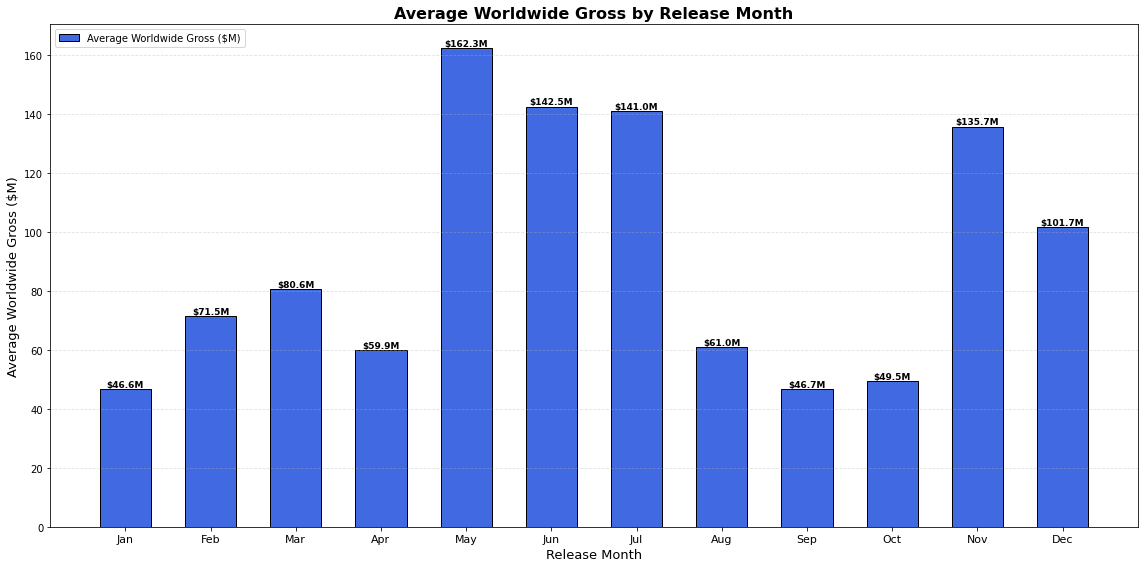

In [39]:
# Create positions for the 12 months
months = monthly_performance.index
x = np.arange(len(months))

# Create the figure
fig, ax1 = plt.subplots(figsize=(16, 8))

# -----------------------------
# AVERAGE WORLDWIDE GROSS
# -----------------------------

bars_gross = ax1.bar(
    x,
    monthly_performance['average_worldwide_gross'],
    width=0.6,
    color='royalblue',
    edgecolor='black',
    label='Average Worldwide Gross ($M)'
)

ax1.set_xlabel('Release Month', fontsize=13)

ax1.set_ylabel(
    'Average Worldwide Gross ($M)',
    fontsize=13
)

ax1.set_title(
    'Average Worldwide Gross by Release Month',
    fontsize=16,
    fontweight='bold'
)

# -----------------------------
# X-AXIS
# -----------------------------

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

ax1.set_xticks(x)
ax1.set_xticklabels(month_labels, fontsize=11)

# -----------------------------
# Add values above the bars
# -----------------------------

for bar in bars_gross:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# -----------------------------
# Grid
# -----------------------------

ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# -----------------------------
# Legend
# -----------------------------

ax1.legend(
    loc='upper left'
)

plt.tight_layout()
plt.show()

## CRISP-DM: 5. Evaluation — Business Question 1

### Which Release Months Perform Best?

#### Conclusion

The analysis indicates that **May–July and November–December are the prime release windows** based on average worldwide gross performance.

The strongest average worldwide gross is observed in **May (approximately $162.3M)**, followed by June and July. December has the highest release volume, showing that **release volume and average financial performance are different measures**.

#### Business Interpretation

Release timing can therefore be considered as one factor in a movie studio's launch strategy, alongside genre, competition, marketing and audience demand.

## Analysis 2: Genre with the Highest ROI

#### Business Question

**Which movie genres generate the highest return on investment?**

We combine movie budget data with IMDb information containing movie titles, genres, audience ratings and vote counts. The analysis uses **median ROI by genre** so the comparison is less influenced by unusually extreme ROI values.

### b) Connect to the IMDb SQLite Database

Create a connection to the SQLite database containing the IMDb movie information.

The connection will be used to retrieve the movie basics and ratings tables.


In [40]:
# Connect to the IMDb SQLite database.
conn = sqlite3.connect('data/im.db/im.db')


### c) Query the Required IMDb Columns

Retrieve only the columns needed for the analysis:

- From `movie_basics`: `movie_id`, `primary_title`, and `genres`
- From `movie_ratings`: `movie_id` and `averagerating`

The shared `movie_id` will later allow us to combine these two tables.


### d) Query the two relevant databse tables and load sql query results into Pandas DataFrame

In [41]:
# Retrieve movie title and genre fields from IMDb.
query_basics = "SELECT movie_id, primary_title, genres FROM movie_basics;"

# Retrieve audience rating fields from IMDb.
query_ratings = "SELECT movie_id, averagerating FROM movie_ratings;"

# Execute the SQL queries and load the results into Pandas DataFrames.
df_basics = pd.read_sql(query_basics, conn)
df_ratings = pd.read_sql(query_ratings, conn)

### e) Inspect The DataFrames from the queries

In [42]:
df_basics.head()

,movie_id,primary_title,genres
0,tt0063540,Sunghursh,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,Drama
3,tt0069204,Sabse Bada Sukh,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,"Comedy,Drama,Fantasy"


In [43]:
df_ratings.head()

,movie_id,averagerating
0,tt10356526,8.3
1,tt10384606,8.9
2,tt1042974,6.4
3,tt1043726,4.2
4,tt1060240,6.5


### f) Merge the IMDb Tables

Combine `movie_basics` and `movie_ratings` using their common `movie_id`.

An inner join keeps only movies that have matching records in both tables.


In [44]:
# Combine IMDb basics and ratings using the shared movie_id.
# The inner join keeps only movies with matching records in both tables.
df_imdb = pd.merge(df_basics, df_ratings, on='movie_id', how='inner')

### g) Inspect Merged Table

In [45]:
df_imdb.head()

,movie_id,primary_title,genres,averagerating
0,tt0063540,Sunghursh,"Action,Crime,Drama",7.0
1,tt0066787,One Day Before the Rainy Season,"Biography,Drama",7.2
2,tt0069049,The Other Side of the Wind,Drama,6.9
3,tt0069204,Sabse Bada Sukh,"Comedy,Drama",6.1
4,tt0100275,The Wandering Soap Opera,"Comedy,Drama,Fantasy",6.5


### 4.10 Combine budget df and IMDb Data

The budget dataset identifies a movie using `movie`, while IMDb identifies it using `primary_title`. We therefore match:

`df.movie` → `df_imdb.primary_title`

The resulting DataFrame combines financial performance with IMDb genre and rating information.

In [46]:
# Merge financial data with IMDb information using movie titles.
# The budget dataset uses 'movie'; IMDb uses 'primary_title'.
df_final = pd.merge(
    df,
    df_imdb,
    left_on='movie',
    right_on='primary_title',
    how='inner'
)

### i) Inspect the new Dataframe

In [47]:

# Display the first few rows of the combined dataset.
df_final.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_month,net_profit,roi,loss_or_profit,movie_id,primary_title,genres,averagerating
0,1,2009-12-18,Avatar,425000000,760507625,2776345279,12,2351345279,553.257713,Profit,tt1775309,Avatar,Horror,6.1
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5,635063875,154.667286,Profit,tt1298650,Pirates of the Caribbean: On Stranger Tides,"Action,Adventure,Fantasy",6.6
2,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,6,-200237650,-57.210757,Loss,tt6565702,Dark Phoenix,"Action,Adventure,Sci-Fi",6.0
3,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,5,1072413963,324.384139,Profit,tt2395427,Avengers: Age of Ultron,"Action,Adventure,Sci-Fi",7.3
4,7,2018-04-27,Avengers: Infinity War,300000000,678815482,2048134200,4,1748134200,582.711400,Profit,tt4154756,Avengers: Infinity War,"Action,Adventure,Sci-Fi",8.5


In [321]:
df.shape

(5782, 10)

### 4.12 Prepare the Final Analysis Dataset

The analysis focuses on movies released from **2010 onward**.

Because the same movie title can appear more than once in IMDb, `numvotes` is used to retain the IMDb record with the highest number of votes for a duplicated title. This creates a cleaner title-level matching process before genre analysis.

In [48]:
# Retrieve IMDb basics plus numvotes from the ratings table.
# numvotes helps select the most representative record when a title is duplicated.
query_basics = "SELECT movie_id, primary_title, genres FROM movie_basics;"
query_ratings = "SELECT movie_id, averagerating, numvotes FROM movie_ratings;"

df_basics = pd.read_sql(query_basics, conn)
df_ratings = pd.read_sql(query_ratings, conn)

# Merge the IMDb tables using movie_id.
df_imdb = pd.merge(df_basics, df_ratings, on='movie_id', how='inner')

# Keep the IMDb record with the highest number of votes for each title.
df_imdb = (
    df_imdb
    .sort_values('numvotes', ascending=False)
    .drop_duplicates(subset=['primary_title'])
)

# Restrict the financial analysis to movies released from 2010 onward.
df_recent = df[df['release_date'].dt.year >= 2010]

# Combine the filtered budget data with the cleaned IMDb title-level data.
df_final = pd.merge(
    df_recent,
    df_imdb,
    left_on='movie',
    right_on='primary_title',
    how='inner'
)

# Inspect the final analysis dataset before genre transformation.
display(df_final.head())

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_month,net_profit,roi,loss_or_profit,movie_id,primary_title,genres,averagerating,numvotes
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5,635063875,154.667286,Profit,tt1298650,Pirates of the Caribbean: On Stranger Tides,"Action,Adventure,Fantasy",6.6,447624
1,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,6,-200237650,-57.210757,Loss,tt6565702,Dark Phoenix,"Action,Adventure,Sci-Fi",6.0,24451
2,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,5,1072413963,324.384139,Profit,tt2395427,Avengers: Age of Ultron,"Action,Adventure,Sci-Fi",7.3,665594
3,7,2018-04-27,Avengers: Infinity War,300000000,678815482,2048134200,4,1748134200,582.711400,Profit,tt4154756,Avengers: Infinity War,"Action,Adventure,Sci-Fi",8.5,670926
4,9,2017-11-17,Justice League,300000000,229024295,655945209,11,355945209,118.648403,Profit,tt0974015,Justice League,"Action,Adventure,Fantasy",6.5,329135


In [323]:
df.shape

(5782, 10)

### 4.13 Prepare Individual Movie Genres

The `genres` field can contain multiple genres in one cell, such as `Action,Adventure,Sci-Fi`.

To analyze genres individually:
1. `.str.split(',')` converts the genre string into a Python list.
2. `.explode()` creates one row per genre.

This allows each genre to be grouped and compared separately.

In [49]:
# Split comma-separated genres into Python lists.
df_final['genre_list'] = df_final['genres'].str.split(',')

# Expand each list so every genre receives its own row.
# This allows one movie to contribute to each of its individual genres.
df_exploded = df_final.explode('genre_list')

In [325]:
df_exploded.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_month,net_profit,roi,loss_or_profit,movie_id,primary_title,genres,averagerating,numvotes,genre_list
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5,635063875,154.667286,Profit,tt1298650,Pirates of the Caribbean: On Stranger Tides,"Action,Adventure,Fantasy",6.6,447624,Action
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5,635063875,154.667286,Profit,tt1298650,Pirates of the Caribbean: On Stranger Tides,"Action,Adventure,Fantasy",6.6,447624,Adventure
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,5,635063875,154.667286,Profit,tt1298650,Pirates of the Caribbean: On Stranger Tides,"Action,Adventure,Fantasy",6.6,447624,Fantasy
1,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,6,-200237650,-57.210757,Loss,tt6565702,Dark Phoenix,"Action,Adventure,Sci-Fi",6.0,24451,Action
1,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,6,-200237650,-57.210757,Loss,tt6565702,Dark Phoenix,"Action,Adventure,Sci-Fi",6.0,24451,Adventure


### 4.14 Calculate Median ROI by Genre

Group the exploded dataset by individual genre and calculate the **median ROI** for each genre. The results are sorted from highest to lowest so the strongest-performing genres can be identified.

In [50]:
# Group by individual genre and calculate median ROI.
# Median reduces the influence of unusually extreme ROI values.
genre_roi = (
    df_exploded
    .groupby('genre_list')['roi']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

### m) Display the first ten genres with the highest median ROI

In [51]:
# Rename the columns.
genre_roi.columns = ['genre', 'median_roi']

# Display the top 10 genres.
genre_roi.head(10)

,genre,median_roi
0,Animation,179.032229
1,Mystery,151.265159
2,Adventure,145.261623
3,Sci-Fi,138.493409
4,Comedy,105.121590
5,Fantasy,103.228583
6,Action,92.557252
7,Family,89.236847
8,Romance,87.655671
9,Music,74.634356


### 4.16 Visualize the Top 10 Genres by Median ROI

Select the ten genres with the highest median ROI and display them in a horizontal bar chart. The visualization makes it easier to compare relative genre-level returns.

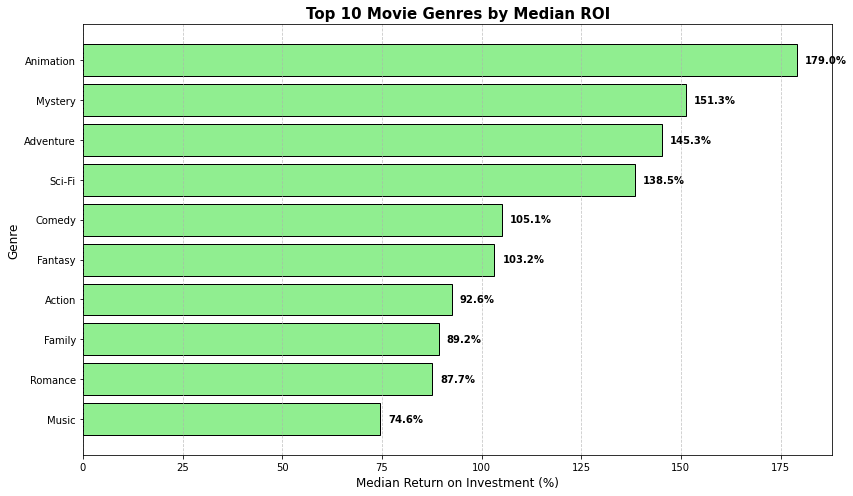

In [52]:
# Select the ten genres with the highest median ROI.
top_genres = genre_roi.head(10)

# Create a horizontal bar chart so genre names remain easy to read.
plt.figure(figsize=(12, 7))
bars = plt.barh(
    top_genres['genre'],
    top_genres['median_roi'],
    color='lightgreen',
    edgecolor='black'
)

# Place the highest-ROI genre at the top of the chart.
plt.gca().invert_yaxis()

# Add exact ROI percentages to the end of each bar.
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Add descriptive title and axis labels.
plt.title('Top 10 Movie Genres by Median ROI', fontsize=15, fontweight='bold')
plt.xlabel('Median Return on Investment (%)', fontsize=12)
plt.ylabel('Genre', fontsize=12)

# Add grid lines to make ROI comparisons easier.
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## CRISP-DM: 5. Evaluation — Business Question 2

### Which Movie Genres Have the Highest ROI?

#### Conclusion

The analysis shows that **Animation has the highest median ROI at 179.0%**, followed by **Mystery (151.3%)**, **Adventure (145.3%)** and **Sci-Fi (138.5%)**. Comedy and Fantasy also exceed 100% median ROI.

#### Business Interpretation

These results indicate that several genres have historically generated strong returns relative to production investment. However, genre should not be considered in isolation; budget, release timing, audience demand, competition and marketing strategy should also inform investment decisions.

## Analytical 3: Impact of Production Budget on Movie Performance

#### Business Question

**How does production budget relate to worldwide gross and audience ratings?**

We use scatter plots and regression lines to investigate two relationships:

1. **Production budget vs. worldwide gross** — whether higher budgets tend to be associated with higher box-office revenue.
2. **Production budget vs. audience rating** — whether higher budgets appear to be associated with higher audience ratings.

This is a **relationship analysis, not a causal model**: a positive association does not prove that increasing the budget causes higher revenue.

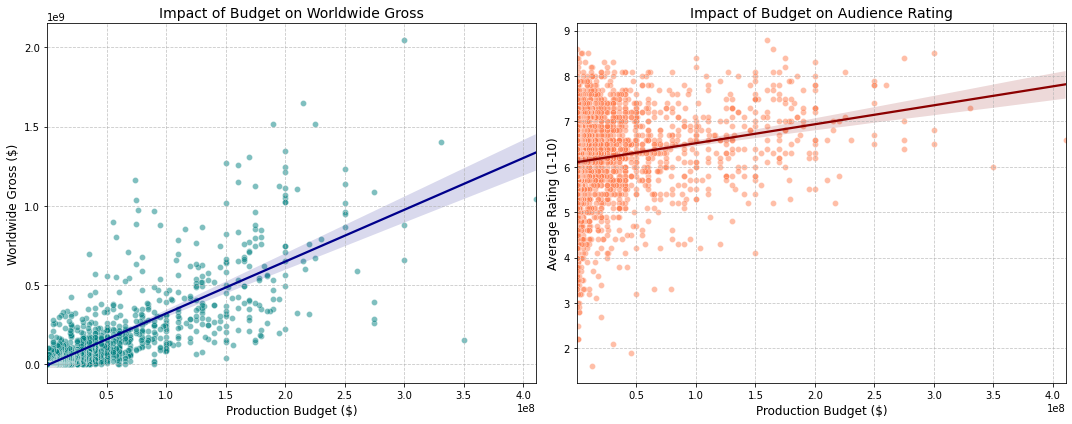

In [53]:
# Create two side-by-side scatter plots to examine relationships between
# production budget and two measures of movie performance.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Production budget vs. worldwide gross.
sns.scatterplot(
    data=df_final, x='production_budget', y='worldwide_gross',
    alpha=0.5, color='teal', ax=axes[0]
)

# Add a regression line to summarize the overall linear relationship.
sns.regplot(
    data=df_final, x='production_budget', y='worldwide_gross',
    scatter=False, color='darkblue', ax=axes[0]
)

axes[0].set_title('Impact of Budget on Worldwide Gross', fontsize=14)
axes[0].set_xlabel('Production Budget ($)', fontsize=12)
axes[0].set_ylabel('Worldwide Gross ($)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Production budget vs. audience rating.
sns.scatterplot(
    data=df_final, x='production_budget', y='averagerating',
    alpha=0.5, color='coral', ax=axes[1]
)

# Add a regression line to summarize the overall relationship.
sns.regplot(
    data=df_final, x='production_budget', y='averagerating',
    scatter=False, color='darkred', ax=axes[1]
)

axes[1].set_title('Impact of Budget on Audience Rating', fontsize=14)
axes[1].set_xlabel('Production Budget ($)', fontsize=12)
axes[1].set_ylabel('Average Rating (1-10)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## CRISP-DM: 5. Evaluation — Business Question 3

### How Does Production Budget Affect Movie Performance?

#### Conclusion

The analysis shows a **positive relationship between production budget and worldwide gross**. In general, movies with larger production budgets tend to generate higher worldwide gross.

However, the relationship is not absolute. Movies with similar budgets can have very different worldwide gross outcomes, so a larger budget does not guarantee commercial success.

The relationship between production budget and audience rating appears relatively weak, suggesting that **spending more on production does not automatically produce higher audience ratings**.

#### Business Interpretation

Production budget should therefore be **optimized rather than simply maximized**. Investment decisions should consider expected revenue, historical ROI, genre, release timing, competition, audience demand and marketing requirements.